In [1]:
import pandas as pd
import shap
import joblib
import matplotlib.pyplot as plt

c:\Users\HP\Desktop\projects\customer-churn-prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("C:\\Users\\HP\\Desktop\\projects\\customer-churn-prediction\\data\\raw\\Telco_Cusomer_Churn.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df = df.dropna()

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df["avg_monthly_spend"] = df["TotalCharges"] / (df["tenure"] + 1)

X = df.drop(["Churn", "customerID"], axis=1)

In [4]:
model = joblib.load("C:/Users/HP/Desktop/projects/customer-churn-prediction/model.pkl")

In [5]:
X_transformed = model.named_steps["preprocess"].transform(X)

In [6]:
explainer = shap.Explainer(model.named_steps["model"])

In [7]:
X_sample = X_transformed[:200]

shap_values = explainer(X_sample)

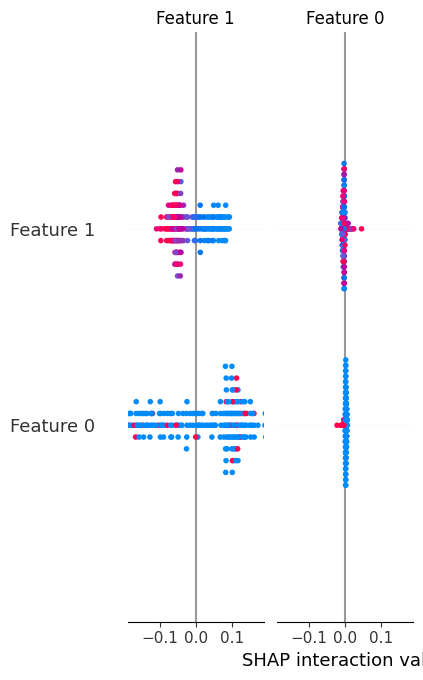

In [8]:
shap.summary_plot(shap_values, X_sample)